In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
entry_df = pd.read_csv(
    "../data/processed/entry_level_emotion_engagement.csv"
)

print(entry_df.shape)
entry_df.head()

(91071, 12)


,entry_id,anger,disgust,fear,joy,neutral,sadness,surprise,CommentCount,like_count,has_like,has_multiple_comments
0,e/0000b70d9f3b1d0a7e78bc2ce09af1a2,0.007657,0.000702,0.001875,0.078348,0.238479,0.023530,0.649409,1,0,0,0
1,e/0000d26daa876fa3165f8808656a30d9,0.302569,0.040035,0.005059,0.006527,0.595786,0.025076,0.024948,1,0,0,0
2,e/00025446898d8328d8272cce96072696,0.022566,0.023315,0.017705,0.004337,0.750684,0.024067,0.157326,1,0,0,0
3,e/0004a4a67a3446d79be082181f50c01b,0.005186,0.002103,0.002399,0.008541,0.790450,0.027148,0.164172,1,0,0,0
4,e/0006970b646d4530991c745db20055b8,0.008938,0.032281,0.002854,0.004950,0.922660,0.016504,0.011814,1,1,1,0


In [4]:
emotion_cols = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
]

X = entry_df[emotion_cols]

print(X.shape)
X.head()

(91071, 7)


,anger,disgust,fear,joy,neutral,sadness,surprise
0,0.007657,0.000702,0.001875,0.078348,0.238479,0.023530,0.649409
1,0.302569,0.040035,0.005059,0.006527,0.595786,0.025076,0.024948
2,0.022566,0.023315,0.017705,0.004337,0.750684,0.024067,0.157326
3,0.005186,0.002103,0.002399,0.008541,0.790450,0.027148,0.164172
4,0.008938,0.032281,0.002854,0.004950,0.922660,0.016504,0.011814


In [5]:
inertias = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(
        X,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"K={k} | "
        f"Inertia={kmeans.inertia_:.2f} | "
        f"Silhouette={score:.4f}"
    )

K=2 | Inertia=12698.85 | Silhouette=0.4962
K=3 | Inertia=9653.16 | Silhouette=0.5418
K=4 | Inertia=7870.38 | Silhouette=0.5309
K=5 | Inertia=6368.85 | Silhouette=0.5555
K=6 | Inertia=5177.01 | Silhouette=0.5743
K=7 | Inertia=4057.21 | Silhouette=0.5049
K=8 | Inertia=3457.27 | Silhouette=0.5151


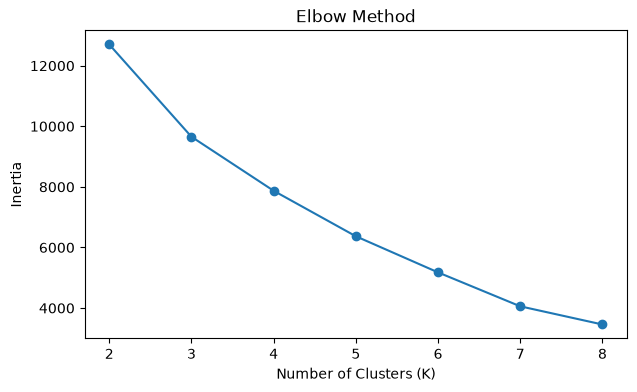

In [6]:
plt.figure(figsize=(7, 4))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

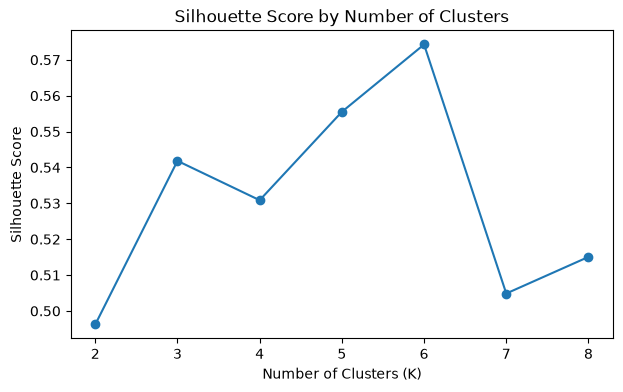

In [7]:
plt.figure(figsize=(7, 4))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

In [8]:
final_kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

entry_df["cluster"] = final_kmeans.fit_predict(X)

print(entry_df["cluster"].value_counts().sort_index())

cluster
0    55870
1     5152
2     6126
3    10365
4     3337
5    10221
Name: count, dtype: int64


In [9]:
cluster_profiles = (
    entry_df
    .groupby("cluster")[emotion_cols]
    .mean()
    .round(3)
)

cluster_profiles

,anger,disgust,fear,joy,neutral,sadness,surprise
cluster,,,,,,,
0,0.017,0.014,0.014,0.050,0.788,0.028,0.089
1,0.043,0.031,0.044,0.031,0.143,0.638,0.070
2,0.386,0.260,0.060,0.022,0.160,0.073,0.038
3,0.031,0.015,0.025,0.115,0.296,0.060,0.458
4,0.054,0.028,0.688,0.021,0.111,0.059,0.038
5,0.015,0.008,0.011,0.651,0.194,0.029,0.093


In [11]:
cluster_names = {
    0: "Neutral-dominant",
    1: "Sadness-dominant",
    2: "Anger-dominant",
    3: "Surprise-dominant",
    4: "Fear-dominant",
    5: "Joy-dominant"
}

entry_df["cluster_name"] = entry_df["cluster"].map(cluster_names)

In [12]:
cluster_summary = (
    entry_df
    .groupby("cluster_name")
    .agg(
        total_entries=("entry_id", "count"),
        avg_likes=("like_count", "mean"),
        median_likes=("like_count", "median"),
        like_rate=("has_like", "mean"),
        avg_comments=("CommentCount", "mean"),
        median_comments=("CommentCount", "median"),
        multiple_comment_rate=("has_multiple_comments", "mean")
    )
)

cluster_summary["like_rate"] *= 100
cluster_summary["multiple_comment_rate"] *= 100

cluster_summary.round(2)

,total_entries,avg_likes,median_likes,like_rate,avg_comments,median_comments,multiple_comment_rate
cluster_name,,,,,,,
Anger-dominant,6126,0.21,0.0,10.38,1.27,1.0,7.30
Fear-dominant,3337,0.12,0.0,4.70,1.03,1.0,2.25
Joy-dominant,10221,0.24,0.0,8.85,1.14,1.0,4.80
Neutral-dominant,55870,0.17,0.0,5.71,1.12,1.0,3.16
Sadness-dominant,5152,0.10,0.0,5.05,1.06,1.0,3.12
Surprise-dominant,10365,0.35,0.0,11.57,1.87,1.0,8.90


In [13]:
cluster_summary.sort_values(
    "like_rate",
    ascending=False
).round(2)

,total_entries,avg_likes,median_likes,like_rate,avg_comments,median_comments,multiple_comment_rate
cluster_name,,,,,,,
Surprise-dominant,10365,0.35,0.0,11.57,1.87,1.0,8.90
Anger-dominant,6126,0.21,0.0,10.38,1.27,1.0,7.30
Joy-dominant,10221,0.24,0.0,8.85,1.14,1.0,4.80
Neutral-dominant,55870,0.17,0.0,5.71,1.12,1.0,3.16
Sadness-dominant,5152,0.10,0.0,5.05,1.06,1.0,3.12
Fear-dominant,3337,0.12,0.0,4.70,1.03,1.0,2.25


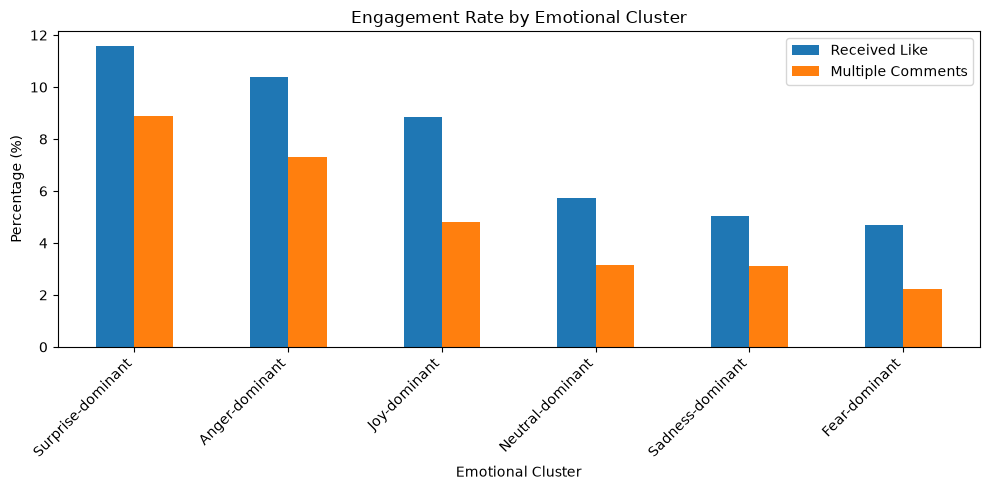

In [14]:
plot_df = (
    cluster_summary[
        ["like_rate", "multiple_comment_rate"]
    ]
    .sort_values("like_rate", ascending=False)
)

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Engagement Rate by Emotional Cluster")
plt.xlabel("Emotional Cluster")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["Received Like", "Multiple Comments"]
)
plt.tight_layout()
plt.show()

In [15]:
entry_df.to_csv(
    "../data/processed/entry_level_with_clusters.csv",
    index=False
)

print("Saved successfully!")
print("Shape:", entry_df.shape)

Saved successfully!
Shape: (91071, 14)
